In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
# Load data
df_products = pd.read_csv('data/raw/products.csv')
df_users = pd.read_csv('data/raw/users.csv')
df_interactions = pd.read_csv('data/raw/interactions.csv')

print("=" * 70)
print(" DATA LOADED")
print("=" * 70)
print(f"✓ Products: {len(df_products)} rows")
print(f"✓ Users: {len(df_users)} rows")
print(f"✓ Interactions: {len(df_interactions)} rows")

# Check data types
print("\n" + "=" * 70)
print("📋 DATA TYPES")
print("=" * 70)
print("\nInteractions dtypes:")
print(df_interactions.dtypes)

 DATA LOADED
✓ Products: 500 rows
✓ Users: 1000 rows
✓ Interactions: 4973 rows

📋 DATA TYPES

Interactions dtypes:
user_id             int64
product_id          int64
interaction_type      str
timestamp             str
rating              int64
dtype: object


In [3]:
# Convert timestamp to datetime
df_interactions['timestamp'] = pd.to_datetime(df_interactions['timestamp'])
df_users['signup_date'] = pd.to_datetime(df_users['signup_date'])

print("✓ Timestamps converted to datetime format")
print(f"\nInteraction date range: {df_interactions['timestamp'].min()} to {df_interactions['timestamp'].max()}")

✓ Timestamps converted to datetime format

Interaction date range: 2023-06-01 00:00:00 to 2023-06-04 11:19:00


In [5]:
print("=" * 70)
print(" ENGINEERING USER FEATURES")
print("=" * 70)

# Initialize user features dataframe
user_features = df_users[['user_id', 'country']].copy()

# 1. Total interactions per user
user_interactions = df_interactions.groupby('user_id').size().reset_index(name='total_interactions')
user_features = user_features.merge(user_interactions, on='user_id', how='left')

# 2. Number of products interacted with
unique_products = df_interactions.groupby('user_id')['product_id'].nunique().reset_index(name='num_products_interacted')
user_features = user_features.merge(unique_products, on='user_id', how='left')

# 3. Average rating given by user
avg_rating = df_interactions.groupby('user_id')['rating'].mean().reset_index(name='avg_rating_given')
user_features = user_features.merge(avg_rating, on='user_id', how='left')

# 4. Most common interaction type
def get_most_common_interaction(user_id):
    user_interactions = df_interactions[df_interactions['user_id'] == user_id]['interaction_type']
    if len(user_interactions) > 0:
        return user_interactions.mode()[0]
    return 'view'

most_common_type = df_interactions.groupby('user_id')['interaction_type'].apply(lambda x: x.mode()[0]).reset_index(name='most_common_interaction')
user_features = user_features.merge(most_common_type, on='user_id', how='left')

# 5. Number of each interaction type
interaction_pivot = df_interactions.groupby(['user_id', 'interaction_type']).size().unstack(fill_value=0)
interaction_pivot.columns = [f'count_{col}' for col in interaction_pivot.columns]
interaction_pivot = interaction_pivot.reset_index()
user_features = user_features.merge(interaction_pivot, on='user_id', how='left')

print("\n✓ User activity features created:")
print(user_features.head())
print(f"\nUser features shape: {user_features.shape}")
print(f"Columns: {user_features.columns.tolist()}")

 ENGINEERING USER FEATURES

✓ User activity features created:
   user_id  country  total_interactions  num_products_interacted  \
0        1      USA                 6.0                      6.0   
1        2      USA                 6.0                      6.0   
2        3      USA                 5.0                      5.0   
3        4       UK                 7.0                      7.0   
4        5  Germany                 7.0                      7.0   

   avg_rating_given most_common_interaction  count_click  count_purchase  \
0          4.166667                   click          2.0             2.0   
1          3.166667                    view          0.0             1.0   
2          3.400000                    view          0.0             0.0   
3          4.000000                    view          0.0             2.0   
4          3.857143                    view          0.0             2.0   

   count_view  count_wishlist  
0         2.0             0.0  
1       

In [6]:
# 6. Days since signup
df_users['signup_date'] = pd.to_datetime(df_users['signup_date'])
reference_date = df_interactions['timestamp'].max()

user_days_since_signup = df_users[['user_id', 'signup_date']].copy()
user_days_since_signup['days_since_signup'] = (reference_date - user_days_since_signup['signup_date']).dt.days
user_days_since_signup = user_days_since_signup[['user_id', 'days_since_signup']]

user_features = user_features.merge(user_days_since_signup, on='user_id', how='left')

# 7. Days since last interaction
last_interaction = df_interactions.groupby('user_id')['timestamp'].max().reset_index(name='last_interaction')
last_interaction['days_since_last_interaction'] = (reference_date - last_interaction['last_interaction']).dt.days
last_interaction = last_interaction[['user_id', 'days_since_last_interaction']]

user_features = user_features.merge(last_interaction, on='user_id', how='left')

# 8. Account age in days
user_features['account_age_days'] = user_features['days_since_signup']

print("✓ Temporal features added")
print(f"\nUser features shape: {user_features.shape}")
print("\nTemporal features:")
print(user_features[['user_id', 'days_since_signup', 'days_since_last_interaction', 'account_age_days']].head())

✓ Temporal features added

User features shape: (1000, 13)

Temporal features:
   user_id  days_since_signup  days_since_last_interaction  account_age_days
0        1                154                          0.0               154
1        2                154                          0.0               154
2        3                154                          0.0               154
3        4                154                          1.0               154
4        5                154                          0.0               154


In [7]:
# 9. Preferred category
df_interactions_with_category = df_interactions.merge(df_products[['product_id', 'category']], on='product_id')

preferred_category = df_interactions_with_category.groupby('user_id')['category'].apply(lambda x: x.mode()[0]).reset_index(name='preferred_category')
user_features = user_features.merge(preferred_category, on='user_id', how='left')

# 10. Average price of products interacted with
avg_product_price = df_interactions_with_category.groupby('user_id').apply(
    lambda x: df_products[df_products['product_id'].isin(x['product_id'])]['price'].mean()
).reset_index(name='avg_product_price')
avg_product_price.columns = ['user_id', 'avg_product_price']

user_features = user_features.merge(avg_product_price, on='user_id', how='left')

# 11. User engagement score (normalized interactions)
max_interactions = user_features['total_interactions'].max()
user_features['engagement_score'] = user_features['total_interactions'] / max_interactions

print("✓ Preference features added")
print(f"\nUser features shape: {user_features.shape}")
print("\nFinal user features:")
print(user_features.head(10))
print(f"\nColumns ({len(user_features.columns)}): {user_features.columns.tolist()}")

✓ Preference features added

User features shape: (1000, 16)

Final user features:
   user_id  country  total_interactions  num_products_interacted  \
0        1      USA                 6.0                      6.0   
1        2      USA                 6.0                      6.0   
2        3      USA                 5.0                      5.0   
3        4       UK                 7.0                      7.0   
4        5  Germany                 7.0                      7.0   
5        6       UK                11.0                     11.0   
6        7    India                 8.0                      8.0   
7        8  Germany                 6.0                      6.0   
8        9       UK                 1.0                      1.0   
9       10      USA                 6.0                      6.0   

   avg_rating_given most_common_interaction  count_click  count_purchase  \
0          4.166667                   click          2.0             2.0   
1          3.166

In [9]:
print("=" * 70)
print(" USER FEATURES SUMMARY")
print("=" * 70)

print("\nBasic statistics:")
print(user_features.describe())

print("\n\nCategorical features:")
print(f"Countries: {user_features['country'].nunique()}")
print(user_features['country'].value_counts())

print(f"\n\nPreferred categories distribution:")
print(user_features['preferred_category'].value_counts())

# Missing values check
print(f"\n\nMissing values:")
print(user_features.isnull().sum())

print("\n✓ User features complete!")

 USER FEATURES SUMMARY

Basic statistics:
           user_id  total_interactions  num_products_interacted  \
count  1000.000000          994.000000               994.000000   
mean    500.500000            5.003018                 5.003018   
std     288.819436            2.102842                 2.102842   
min       1.000000            1.000000                 1.000000   
25%     250.750000            4.000000                 4.000000   
50%     500.500000            5.000000                 5.000000   
75%     750.250000            6.000000                 6.000000   
max    1000.000000           14.000000                14.000000   

       avg_rating_given  count_click  count_purchase  count_view  \
count        994.000000   994.000000      994.000000  994.000000   
mean           3.837134     0.991952        0.958753    2.511066   
std            0.582132     0.982186        0.970516    1.523359   
min            1.000000     0.000000        0.000000    0.000000   
25%           

In [11]:
print("=" * 70)
print(" ENGINEERING PRODUCT FEATURES")
print("=" * 70)

# Initialize product features
product_features = df_products[['product_id', 'category', 'price']].copy()

# 1. Total interactions per product
product_interactions = df_interactions.groupby('product_id').size().reset_index(name='total_interactions')
product_features = product_features.merge(product_interactions, on='product_id', how='left')

# 2. Number of users interacted
unique_users = df_interactions.groupby('product_id')['user_id'].nunique().reset_index(name='num_users')
product_features = product_features.merge(unique_users, on='product_id', how='left')

# 3. Average rating received
avg_product_rating = df_interactions.groupby('product_id')['rating'].mean().reset_index(name='avg_rating')
product_features = product_features.merge(avg_product_rating, on='product_id', how='left')

# 4. Rating count (how many ratings)
rating_count = df_interactions[df_interactions['rating'].notna()].groupby('product_id').size().reset_index(name='rating_count')
product_features = product_features.merge(rating_count, on='product_id', how='left')

# 5. Interaction types breakdown
interaction_pivot = df_interactions.groupby(['product_id', 'interaction_type']).size().unstack(fill_value=0)
interaction_pivot.columns = [f'count_{col}' for col in interaction_pivot.columns]
interaction_pivot = interaction_pivot.reset_index()
product_features = product_features.merge(interaction_pivot, on='product_id', how='left')

print("✓ Product popularity features created:")
print(product_features.head())
print(f"\nProduct features shape: {product_features.shape}")

 ENGINEERING PRODUCT FEATURES
✓ Product popularity features created:
   product_id  category       price  total_interactions  num_users  \
0           1    Sports  337.230763                   6          6   
1           2    Sports  497.018912                   8          8   
2           3    Sports  478.531756                   7          7   
3           4  Clothing  431.148377                  11         11   
4           5      Home  394.196088                   8          8   

   avg_rating  rating_count  count_click  count_purchase  count_view  \
0    3.333333             6            1               2           3   
1    3.750000             8            1               1           5   
2    4.142857             7            2               3           2   
3    3.636364            11            0               2           8   
4    3.875000             8            1               0           6   

   count_wishlist  
0               0  
1               1  
2               0

In [12]:
# 6. Purchase rate (purchases / total interactions)
product_features['purchase_rate'] = (product_features.get('count_purchase', 0) / 
                                     product_features['total_interactions']).fillna(0)

# 7. Click-through rate (clicks / views)
views = product_features.get('count_view', 0)
clicks = product_features.get('count_click', 0)
product_features['ctr'] = np.where(views > 0, clicks / views, 0)

# 8. Wishlist rate (wishlist / views)
wishlist = product_features.get('count_wishlist', 0)
product_features['wishlist_rate'] = np.where(views > 0, wishlist / views, 0)

# 9. Price tier (low, medium, high)
price_quartiles = df_products['price'].quantile([0.33, 0.66])
def get_price_tier(price):
    if price <= price_quartiles[0.33]:
        return 'low'
    elif price <= price_quartiles[0.66]:
        return 'medium'
    else:
        return 'high'

product_features['price_tier'] = product_features['price'].apply(get_price_tier)

# 10. Popularity score (normalized interactions)
max_prod_interactions = product_features['total_interactions'].max()
product_features['popularity_score'] = product_features['total_interactions'] / max_prod_interactions

# 11. Quality score (based on average rating)
product_features['quality_score'] = product_features['avg_rating'] / 5.0

print("✓ Quality and engagement features created")
print(f"\nProduct features shape: {product_features.shape}")
print("\nSample features:")
print(product_features[['product_id', 'category', 'price', 'price_tier', 
                         'total_interactions', 'avg_rating', 'purchase_rate', 
                         'ctr', 'popularity_score', 'quality_score']].head(10))

✓ Quality and engagement features created

Product features shape: (500, 17)

Sample features:
   product_id     category       price price_tier  total_interactions  \
0           1       Sports  337.230763     medium                   6   
1           2       Sports  497.018912       high                   8   
2           3       Sports  478.531756       high                   7   
3           4     Clothing  431.148377       high                  11   
4           5         Home  394.196088       high                   8   
5           6  Electronics  402.700272       high                  10   
6           7     Clothing  443.418056       high                   6   
7           8  Electronics  227.592847     medium                  12   
8           9        Books  166.209454        low                  10   
9          10        Books  274.112829     medium                   8   

   avg_rating  purchase_rate       ctr  popularity_score  quality_score  
0    3.333333       0.33333

In [13]:
print("=" * 70)
print(" PRODUCT FEATURES SUMMARY")
print("=" * 70)

print("\nNumerical features:")
print(product_features.describe())

print("\n\nCategorical features:")
print(f"Categories: {product_features['category'].nunique()}")
print(product_features['category'].value_counts())

print(f"\n\nPrice tiers:")
print(product_features['price_tier'].value_counts())

print(f"\n\nMissing values:")
print(product_features.isnull().sum())

print("\n✓ Product features complete!")

 PRODUCT FEATURES SUMMARY

Numerical features:
       product_id       price  total_interactions   num_users  avg_rating  \
count  500.000000  500.000000          500.000000  500.000000  500.000000   
mean   250.500000  266.820968            9.946000    9.946000    3.824766   
std    144.481833  143.739487            2.920298    2.920298    0.390473   
min      1.000000   12.113063            1.000000    1.000000    2.714286   
25%    125.750000  141.006711            8.000000    8.000000    3.555556   
50%    250.500000  280.027846           10.000000   10.000000    3.833333   
75%    375.250000  393.314276           12.000000   12.000000    4.100000   
max    500.000000  497.809450           20.000000   20.000000    5.000000   

       rating_count  count_click  count_purchase  count_view  count_wishlist  \
count    500.000000   500.000000      500.000000   500.00000      500.000000   
mean       9.946000     1.972000        1.906000     4.99200        1.076000   
std        2.920298

In [14]:
print("=" * 70)
print(" BUILDING INTERACTION MATRIX")
print("=" * 70)

# Create user-product interaction matrix (pivot table)
# We'll use the maximum rating as the interaction value
interaction_matrix = df_interactions.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='max',  # Take the maximum rating if multiple interactions
    fill_value=0    # Fill missing with 0 (no interaction)
)

print(f"\nInteraction Matrix Shape: {interaction_matrix.shape}")
print(f"  Rows (users): {interaction_matrix.shape[0]}")
print(f"  Columns (products): {interaction_matrix.shape[1]}")

# Calculate sparsity
total_elements = interaction_matrix.shape[0] * interaction_matrix.shape[1]
non_zero_elements = (interaction_matrix != 0).sum().sum()
sparsity = (1 - (non_zero_elements / total_elements)) * 100

print(f"\nMatrix Sparsity: {sparsity:.2f}%")
print(f"Matrix Density: {100 - sparsity:.2f}%")
print(f"Non-zero elements: {non_zero_elements:,}")

print("\nInteraction Matrix (first 5x5):")
print(interaction_matrix.iloc[:5, :5])

 BUILDING INTERACTION MATRIX

Interaction Matrix Shape: (994, 500)
  Rows (users): 994
  Columns (products): 500

Matrix Sparsity: 99.00%
Matrix Density: 1.00%
Non-zero elements: 4,973

Interaction Matrix (first 5x5):
product_id  1  2  3  4  5
user_id                  
1           0  0  0  0  0
2           0  0  0  0  0
3           0  0  0  0  0
4           0  0  0  0  0
5           0  0  0  0  0


In [15]:
# Create binary interaction matrix (1 = interaction, 0 = no interaction)
binary_interaction_matrix = (df_interactions.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='max',
    fill_value=0
) > 0).astype(int)

print("=" * 70)
print("BINARY INTERACTION MATRIX (1 = interaction, 0 = no)")
print("=" * 70)

print(f"\nBinary Matrix Shape: {binary_interaction_matrix.shape}")
print(f"Non-zero elements: {(binary_interaction_matrix != 0).sum().sum():,}")

print("\nBinary Interaction Matrix (first 5x5):")
print(binary_interaction_matrix.iloc[:5, :5])

print("\nFor recommendation systems, we'll use both:")
print("  • Rating matrix: For rating prediction (SVD, NMF)")
print("  • Binary matrix: For implicit feedback (NCF, ALS)")

BINARY INTERACTION MATRIX (1 = interaction, 0 = no)

Binary Matrix Shape: (994, 500)
Non-zero elements: 4,973

Binary Interaction Matrix (first 5x5):
product_id  1  2  3  4  5
user_id                  
1           0  0  0  0  0
2           0  0  0  0  0
3           0  0  0  0  0
4           0  0  0  0  0
5           0  0  0  0  0

For recommendation systems, we'll use both:
  • Rating matrix: For rating prediction (SVD, NMF)
  • Binary matrix: For implicit feedback (NCF, ALS)


In [16]:
# Save matrices for later use
interaction_matrix.to_csv('data/processed/interaction_matrix_ratings.csv')
binary_interaction_matrix.to_csv('data/processed/interaction_matrix_binary.csv')

# Also save as numpy arrays for faster loading
np.save('data/processed/interaction_matrix_ratings.npy', interaction_matrix.values)
np.save('data/processed/interaction_matrix_binary.npy', binary_interaction_matrix.values)

# Save user and product mappings
user_id_mapping = pd.DataFrame({
    'user_index': range(len(interaction_matrix.index)),
    'user_id': interaction_matrix.index
})
product_id_mapping = pd.DataFrame({
    'product_index': range(len(interaction_matrix.columns)),
    'product_id': interaction_matrix.columns
})

user_id_mapping.to_csv('data/processed/user_id_mapping.csv', index=False)
product_id_mapping.to_csv('data/processed/product_id_mapping.csv', index=False)

print("✓ Interaction matrices saved:")
print("  • data/processed/interaction_matrix_ratings.csv")
print("  • data/processed/interaction_matrix_binary.csv")
print("  • data/processed/user_id_mapping.csv")
print("  • data/processed/product_id_mapping.csv")

✓ Interaction matrices saved:
  • data/processed/interaction_matrix_ratings.csv
  • data/processed/interaction_matrix_binary.csv
  • data/processed/user_id_mapping.csv
  • data/processed/product_id_mapping.csv


In [17]:
print("=" * 70)
print(" TRAIN-TEST SPLIT (TIME-BASED)")
print("=" * 70)

# Sort by timestamp
df_interactions_sorted = df_interactions.sort_values('timestamp').reset_index(drop=True)

# Time-based split: 80% train, 20% test
split_ratio = 0.8
split_index = int(len(df_interactions_sorted) * split_ratio)

df_train = df_interactions_sorted.iloc[:split_index].copy()
df_test = df_interactions_sorted.iloc[split_index:].copy()

print(f"\nTotal interactions: {len(df_interactions)}")
print(f"Training set: {len(df_train)} ({len(df_train)/len(df_interactions)*100:.1f}%)")
print(f"Test set: {len(df_test)} ({len(df_test)/len(df_interactions)*100:.1f}%)")

print(f"\nDate ranges:")
print(f"Training: {df_train['timestamp'].min()} to {df_train['timestamp'].max()}")
print(f"Test: {df_test['timestamp'].min()} to {df_test['timestamp'].max()}")

# Check coverage
print(f"\nTraining set coverage:")
print(f"  Users: {df_train['user_id'].nunique()}")
print(f"  Products: {df_train['product_id'].nunique()}")

print(f"\nTest set coverage:")
print(f"  Users: {df_test['user_id'].nunique()}")
print(f"  Products: {df_test['product_id'].nunique()}")

# New users in test (cold-start problem)
new_users = set(df_test['user_id'].unique()) - set(df_train['user_id'].unique())
new_products = set(df_test['product_id'].unique()) - set(df_train['product_id'].unique())

print(f"\nCold-start problem:")
print(f"  New users in test: {len(new_users)} ({len(new_users)/len(df_test['user_id'].unique())*100:.1f}%)")
print(f"  New products in test: {len(new_products)} ({len(new_products)/len(df_test['product_id'].unique())*100:.1f}%)")

 TRAIN-TEST SPLIT (TIME-BASED)

Total interactions: 4973
Training set: 3978 (80.0%)
Test set: 995 (20.0%)

Date ranges:
Training: 2023-06-01 00:00:00 to 2023-06-03 18:43:00
Test: 2023-06-03 18:44:00 to 2023-06-04 11:19:00

Training set coverage:
  Users: 984
  Products: 500

Test set coverage:
  Users: 637
  Products: 435

Cold-start problem:
  New users in test: 10 (1.6%)
  New products in test: 0 (0.0%)


In [18]:
# Create train interaction matrix
train_interaction_matrix = df_train.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='max',
    fill_value=0
)

# Create test interaction matrix
test_interaction_matrix = df_test.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='max',
    fill_value=0
)

# Align dimensions (ensure all users and products are in both)
all_users = sorted(set(df_train['user_id'].unique()) | set(df_test['user_id'].unique()))
all_products = sorted(set(df_train['product_id'].unique()) | set(df_test['product_id'].unique()))

train_interaction_matrix = train_interaction_matrix.reindex(
    index=all_users, columns=all_products, fill_value=0
)
test_interaction_matrix = test_interaction_matrix.reindex(
    index=all_users, columns=all_products, fill_value=0
)

print("=" * 70)
print("✓ TRAIN-TEST MATRICES CREATED")
print("=" * 70)

print(f"\nTrain matrix shape: {train_interaction_matrix.shape}")
print(f"Test matrix shape: {test_interaction_matrix.shape}")

# Save matrices
train_interaction_matrix.to_csv('data/processed/train_interaction_matrix.csv')
test_interaction_matrix.to_csv('data/processed/test_interaction_matrix.csv')

np.save('data/processed/train_interaction_matrix.npy', train_interaction_matrix.values)
np.save('data/processed/test_interaction_matrix.npy', test_interaction_matrix.values)

print("\n✓ Train-test matrices saved")

# Save train and test CSV
df_train.to_csv('data/processed/interactions_train.csv', index=False)
df_test.to_csv('data/processed/interactions_test.csv', index=False)

print("✓ Train-test interactions saved")

✓ TRAIN-TEST MATRICES CREATED

Train matrix shape: (994, 500)
Test matrix shape: (994, 500)

✓ Train-test matrices saved
✓ Train-test interactions saved


In [19]:
print("=" * 70)
print("SAVING ENGINEERED FEATURES")
print("=" * 70)

# Save user features
user_features.to_csv('data/processed/user_features.csv', index=False)
print(f"\n✓ User features saved ({user_features.shape[0]} users, {user_features.shape[1]} features)")

# Save product features
product_features.to_csv('data/processed/product_features.csv', index=False)
print(f"✓ Product features saved ({product_features.shape[0]} products, {product_features.shape[1]} features)")

# Display feature columns
print(f"\nUser feature columns ({len(user_features.columns)}):")
for i, col in enumerate(user_features.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nProduct feature columns ({len(product_features.columns)}):")
for i, col in enumerate(product_features.columns, 1):
    print(f"  {i:2d}. {col}")

SAVING ENGINEERED FEATURES

✓ User features saved (1000 users, 16 features)
✓ Product features saved (500 products, 17 features)

User feature columns (16):
   1. user_id
   2. country
   3. total_interactions
   4. num_products_interacted
   5. avg_rating_given
   6. most_common_interaction
   7. count_click
   8. count_purchase
   9. count_view
  10. count_wishlist
  11. days_since_signup
  12. days_since_last_interaction
  13. account_age_days
  14. preferred_category
  15. avg_product_price
  16. engagement_score

Product feature columns (17):
   1. product_id
   2. category
   3. price
   4. total_interactions
   5. num_users
   6. avg_rating
   7. rating_count
   8. count_click
   9. count_purchase
  10. count_view
  11. count_wishlist
  12. purchase_rate
  13. ctr
  14. wishlist_rate
  15. price_tier
  16. popularity_score
  17. quality_score


📊 USER FEATURE DISTRIBUTIONS


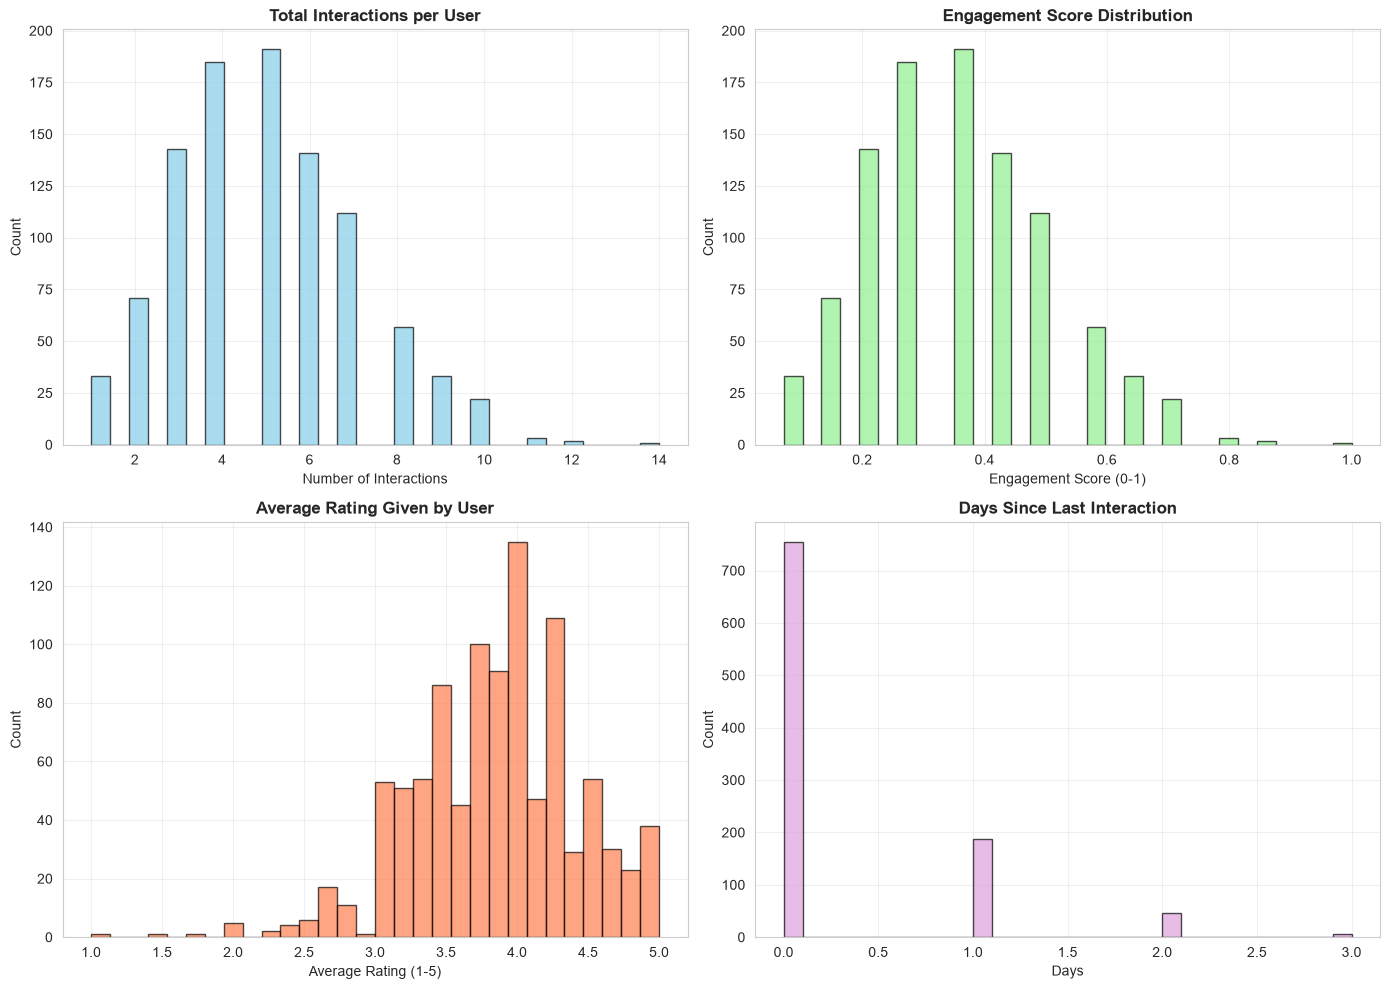

✓ User feature distributions visualized


In [21]:
print("=" * 70)
print("📊 USER FEATURE DISTRIBUTIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total interactions
axes[0, 0].hist(user_features['total_interactions'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Total Interactions per User', fontweight='bold')
axes[0, 0].set_xlabel('Number of Interactions')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, alpha=0.3)

# Engagement score
axes[0, 1].hist(user_features['engagement_score'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Engagement Score Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Engagement Score (0-1)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3)

# Average rating
axes[1, 0].hist(user_features['avg_rating_given'].dropna(), bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Rating Given by User', fontweight='bold')
axes[1, 0].set_xlabel('Average Rating (1-5)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3)

# Days since last interaction
axes[1, 1].hist(user_features['days_since_last_interaction'].dropna(), bins=30, color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Days Since Last Interaction', fontweight='bold')
axes[1, 1].set_xlabel('Days')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ User feature distributions visualized")

📦 PRODUCT FEATURE DISTRIBUTIONS


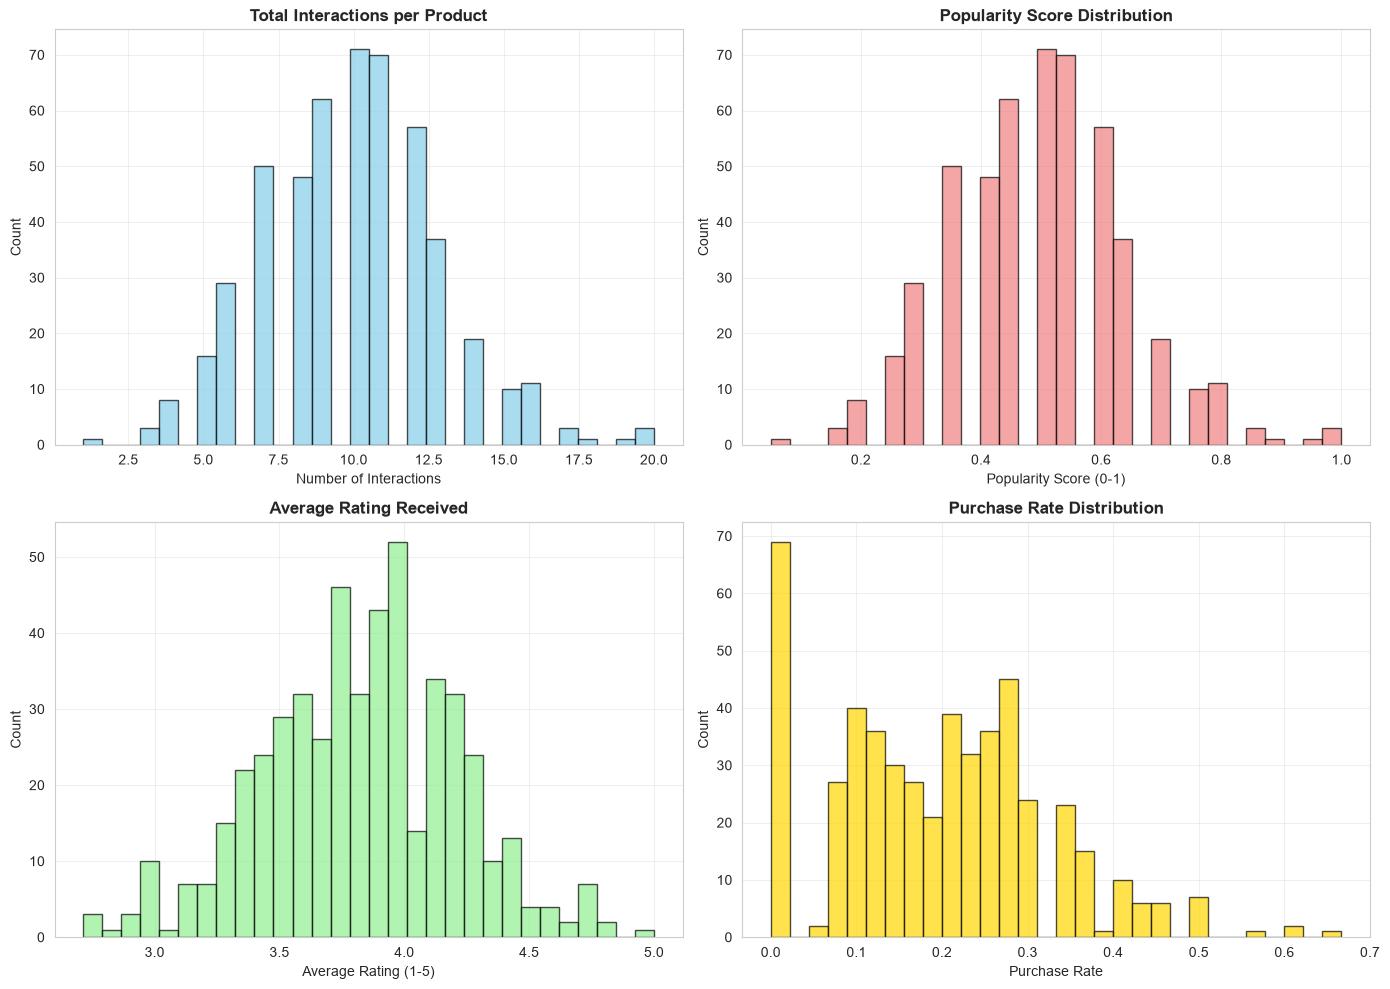

✓ Product feature distributions visualized


In [22]:
print("=" * 70)
print("📦 PRODUCT FEATURE DISTRIBUTIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total interactions
axes[0, 0].hist(product_features['total_interactions'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Total Interactions per Product', fontweight='bold')
axes[0, 0].set_xlabel('Number of Interactions')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, alpha=0.3)

# Popularity score
axes[0, 1].hist(product_features['popularity_score'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Popularity Score Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Popularity Score (0-1)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3)

# Average rating
axes[1, 0].hist(product_features['avg_rating'].dropna(), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Rating Received', fontweight='bold')
axes[1, 0].set_xlabel('Average Rating (1-5)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3)

# Purchase rate
axes[1, 1].hist(product_features['purchase_rate'], bins=30, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Purchase Rate Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Purchase Rate')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Product feature distributions visualized")

🔗 FEATURE CORRELATION ANALYSIS


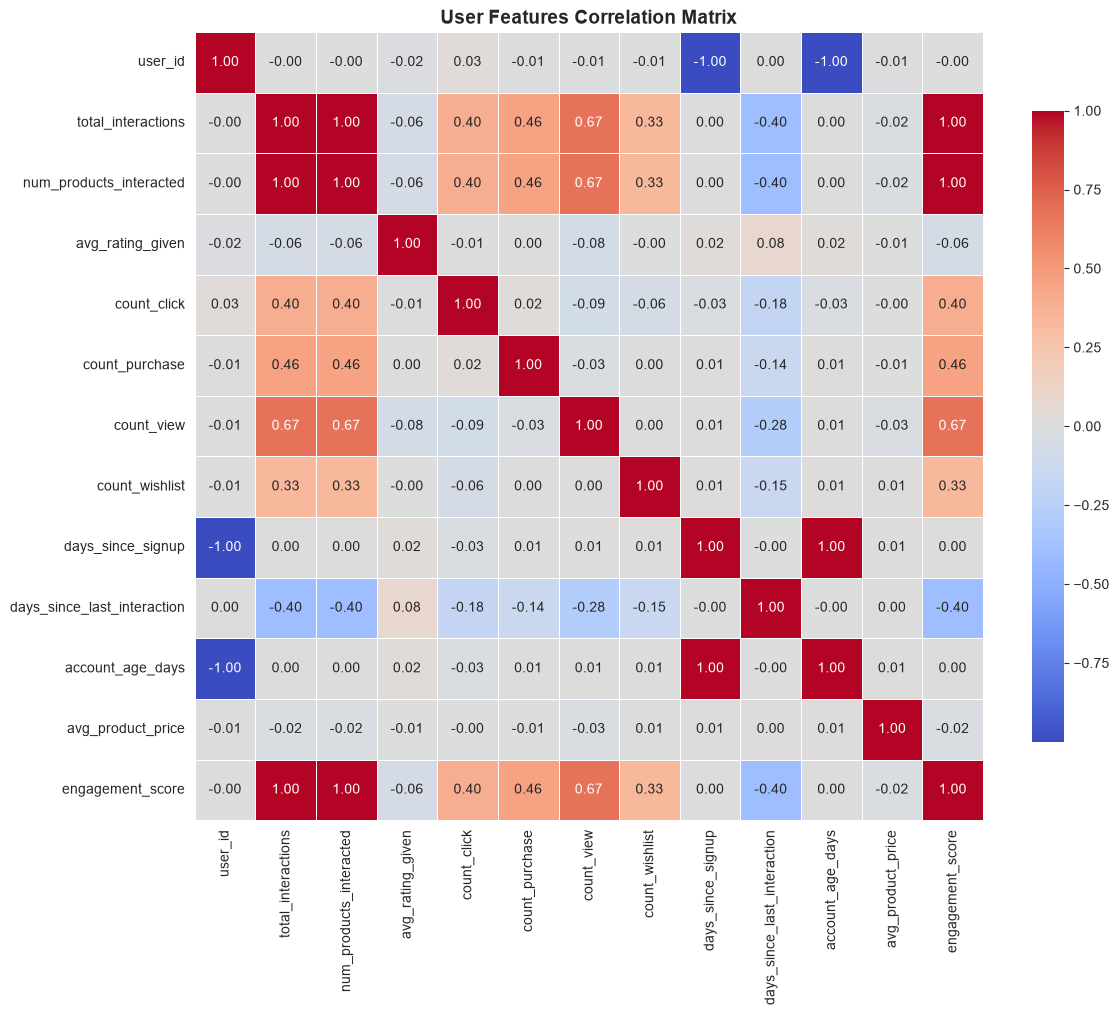

✓ User feature correlations analyzed


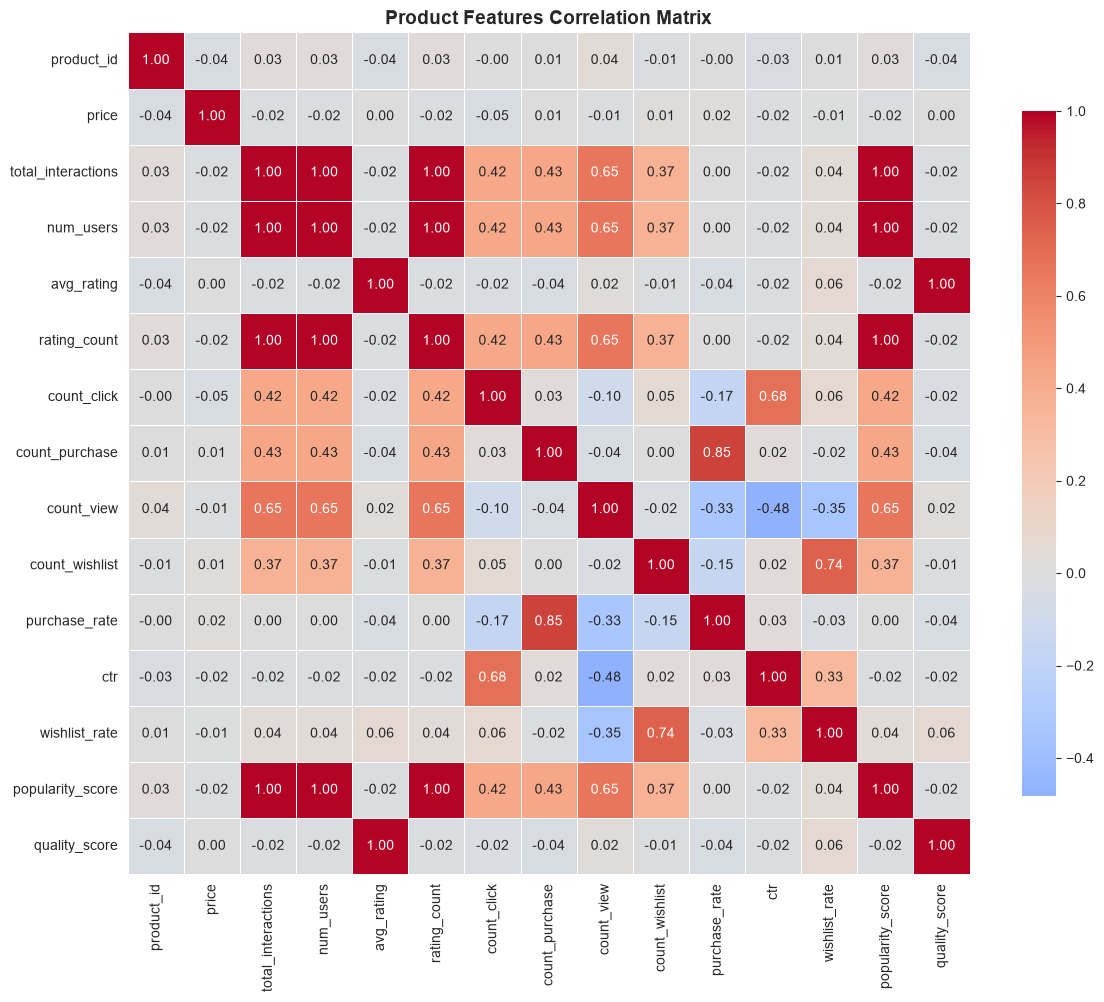

✓ Product feature correlations analyzed


In [23]:
print("=" * 70)
print("🔗 FEATURE CORRELATION ANALYSIS")
print("=" * 70)

# Select numerical columns for correlation
user_numeric = user_features.select_dtypes(include=[np.number])
product_numeric = product_features.select_dtypes(include=[np.number])

# User correlation
user_corr = user_numeric.corr()

# Plot user correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(user_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('User Features Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("✓ User feature correlations analyzed")

# Plot product correlation heatmap
plt.figure(figsize=(12, 10))
product_corr = product_numeric.corr()
sns.heatmap(product_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Product Features Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("✓ Product feature correlations analyzed")